In [1]:
import warnings
warnings.filterwarnings('ignore')
import random, os
import itertools
import json
import multiprocessing as mp
import numpy as np
import pandas as pd
import scipy
from scipy.optimize import curve_fit
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
species_list = ["human", "fly"]
columns = ["0h-1", "0h-2", "3h-1", "3h-2", "6h-1", "6h-2"]
samples = ["20221128_K562_Actd_%dh_rep%d" % (t, r) for t, r in itertools.product([0, 3, 6], [1, 2])]

# Merge gene counts

Outputs:

    results/merged_gene_counts.{species}.csv

In [4]:
for species in species_list:
    outfile = "results/merged_gene_counts.%s.csv" % species
    if os.path.exists(outfile):
        continue
    ss = []
    for sample in samples:
        path = "../../results/1_rnaseq/3_quantify/fpkm/rmdup/%s/%s.tsv" % (species, sample)
        d = pd.read_csv(path, sep="\t", index_col=0)
        d = d[(d["GeneType"] == "protein_coding") & (d["Canonical"])]
        d = d[~d["GeneName"].duplicated()]
        s = d["Count"]
        s.name = sample
        s.index = d["GeneName"]
        ss.append(s)
    m = pd.concat(ss, axis=1)
    m.columns = columns
    m.to_csv(outfile)

# Correlation of gene counts

Outputs:

    figures/correlation_of_gene_counts.{species}.pdf

human
(19956, 6)
(9288, 6)


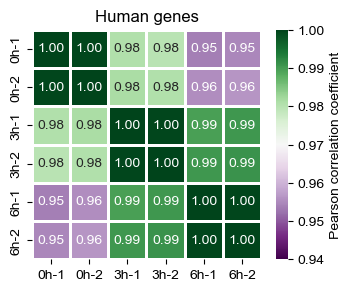

fly
(13968, 6)
(5170, 6)


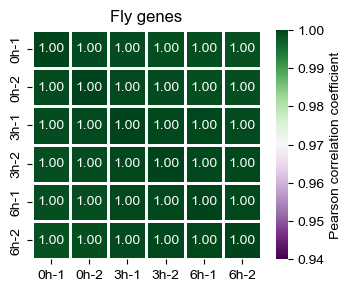

In [7]:
for species in species_list:
    path1 = "results/merged_gene_counts.%s.csv" % species
    path2 = "figures/correlation_of_gene_counts.%s.pdf" % species
    # if os.path.exists(path2):
    #     continue
        
    print(species)
    m = pd.read_csv(path1, index_col=0)
    print(m.shape)
    tmp = m[m.mean(axis=1) >= 100]
    print(tmp.shape)
    corr = tmp.corr()
    vmin = 0.94
    plt.figure(figsize=(3.7, 3))
    if species == "human":
        plt.title("Human genes")
    else:
        plt.title("Fly genes")
    sns.heatmap(corr, cmap="PRGn", vmin=vmin, vmax=1, 
                annot=True, fmt=".2f", lw=1, square=True, 
                cbar_kws=dict(label="Pearson correlation coefficient"))
    plt.tight_layout()
    plt.savefig(path2, dpi=300)
    plt.show()
    plt.close()

# Estimation of conversion factor

Outputs:

    figures/scatter_of_conversion_factor.pdf
    results/conversion_factors.json

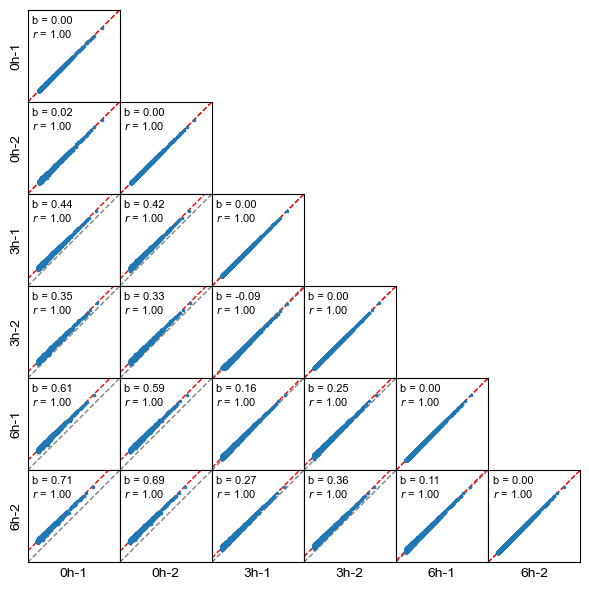

In [9]:
def estimate_k(xs, ys):
    xs = np.log(xs)
    ys = np.log(ys)
    b = (sum(ys) - sum(xs)) / len(xs)
    k = np.e ** b
    return k
    
path1 = "results/merged_gene_counts.fly.csv"
path2 = "figures/scatter_of_conversion_factor.pdf"
path3 = "results/conversion_factors.json"

m = pd.read_csv(path1, index_col=0)
factors = dict()
fig, axs = plt.subplots(len(columns), len(columns), figsize=(6, 6))
for i in range(len(columns)):
    for j in range(len(columns)):
        c1, c2 = columns[j], columns[i]
        xs, ys = m[c1], m[c2]
        flags = (xs > 500) & (ys > 500)
        xs, ys = xs[flags], ys[flags]
        k = estimate_k(xs, ys)
        b = np.log(k)
        xs, ys = np.log(xs), np.log(ys)
        r = scipy.stats.pearsonr(xs, ys)[0]
        
        a1, b1 = np.polyfit(xs, ys, 1)
        vmin = min(min(xs), min(ys)) * 0.9
        vmax = max(max(xs), max(ys)) * 1.1
        factors["%s,%s" % (c1, c2)] = k
        if j > i:
            axs[i][j].set_visible(False)
            continue
        plt.sca(axs[i][j])
        plt.scatter(xs, ys, marker=".", alpha=1, color="C0", s=10, zorder=10)
        plt.xlim(vmin, vmax)
        plt.ylim(vmin, vmax)
        plt.plot([vmin, vmax], [vmin, vmax], ls="--", lw=1, color="grey")
        plt.plot([vmin, vmax], [vmin + b, vmax + b], ls="--", lw=1, color="red")
        w = vmax - vmin
        plt.text(vmin + w * 0.05, vmin + w * 0.85, "b = %.2f" % b, size=8)
        plt.text(vmin + w * 0.05, vmin + w * 0.70, "$r$ = %.2f" % r, size=8)
        if i == len(columns) - 1:
            plt.xlabel(c1)
        else:
            plt.xticks([])
        if j == 0:
            plt.ylabel(c2)
        else:
            plt.yticks([])
        plt.xticks([])
        plt.yticks([])
plt.tight_layout(w_pad=0, h_pad=0)
plt.savefig(path2, dpi=300)
plt.show()
plt.close()

with open(path3, "w+") as fw:
    json.dump(factors, fw, indent=4)

# Estimation of half-life

Outputs:

    results/halflife_of_k562_genes.tsv
    

In [29]:
def decay_rate_curve(t, k):
    return np.exp(-k*t)
    
def fit_decay_rate(ys):
    k, r2 = np.nan, np.nan
    try:
        xs = np.array([0, 0, 3, 3, 6, 6])
        popt, pcov = curve_fit(decay_rate_curve, xs, ys, bounds=(0, 10))
        k = popt[0]
        r2 = r2_score(ys, np.array([decay_rate_curve(x, k) for x in xs]))
    except Exception as e:
        print(e)
    return k, r2

## Half-life of genes

In [19]:
# Merge counts

array = []
for sample, c in zip(samples, columns):
    path = "../../results/1_rnaseq/3_quantify/fpkm/rmdup/human/%s.tsv" % sample
    df = pd.read_csv(path, sep="\t", index_col=0)
    tmp = df[(df["Canonical"]) & (df["TranscriptType"] == "protein_coding")]
    total = sum(tmp["Count"] * 1e2 / tmp["Length"])
    df["TPM"] = df["Count"] * 1e2 / df["Length"] * 1e6 / total
    s = df["FPKM"]
    s.name = "FPKM.%s" % c
    array.append(s)
    s = df["Count"]
    s.name = "Count.%s" % c
    array.append(s)
    s = df["TPM"]
    s.name = "TPM.%s" % c
    array.append(s)
m = pd.concat(array, axis=1)
m = m[list(sorted(m.columns))]
print(m.shape)

(244939, 18)


In [21]:
# Normalized
factors = json.load(open("results/conversion_factors.json"))
for c in columns:
    factor = factors["%s,%s" % (c, "0h-1")]
    m["Count.%s.norm" % c] = m["Count.%s" % c] * factor

In [22]:
# Relative abundance
mean_0 = m[["Count.0h-1.norm", "Count.0h-2.norm"]].mean(axis=1)
for c in columns:
    m["Abundance.%s" % c] = m["Count.%s.norm" % c] / mean_0

In [26]:
# decay rate curve fitting
Ks = []
Rs = []
for i, ys in enumerate(m[["Abundance.%s" % c for c in columns]].values):
    if i % 10000 == 0:
        print("%d/%d" % (i, m.shape[0]))
    k, r2 = fit_decay_rate(ys)
    Ks.append(k)
    Rs.append(r2)
m["DecayRate"] = Ks
m["DecayRate.R2Score"] = Rs
m["Halflife"] = np.log(2) / m["DecayRate"]

0/244939
10000/244939
20000/244939
30000/244939
40000/244939
50000/244939
60000/244939
70000/244939
80000/244939
90000/244939
100000/244939
110000/244939
120000/244939
130000/244939
140000/244939
150000/244939
160000/244939
170000/244939
180000/244939
190000/244939
200000/244939
210000/244939
220000/244939
230000/244939
240000/244939


In [27]:
anno = pd.read_csv("../../share/homo_sapiens/GRCh38.p13/gencode.v39.transcript_info.added_canonical.csv", index_col=0)
anno.drop(columns=["Length"])
m2 = m.merge(anno, left_index=True, right_index=True)
m2.to_csv("results/halflife_of_k562_genes.tsv", sep="\t")

### Plot r2 score distribution

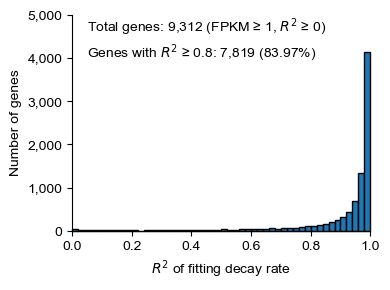

In [16]:
m = pd.read_csv("results/halflife_of_k562_genes.tsv", sep="\t", index_col=0)
m = m[(m["GeneType"] == "protein_coding") & (m["Canonical"])]
m = m[~m["GeneID"].duplicated()]
m = m[(m["FPKM.0h-1"] >= 1) & (m["FPKM.0h-2"] >= 1) & (m["DecayRate.R2Score"] >= 0)]

plt.figure(figsize=(4, 3))
ret = plt.hist(m["DecayRate.R2Score"], range=(0, 1), bins=50, edgecolor="black", color="C0", clip_on=False)
plt.xlim(0, 1)
ylim = 5000
plt.ylim(0, ylim)
plt.text(0.05, ylim * 0.92, r"Total genes: %s (FPKM ≥ 1, $\it{R}^2$ ≥ 0)" % format(len(m), ","))
n = len(m[m["DecayRate.R2Score"] >= 0.8])
plt.text(0.05, ylim * 0.8, "Genes with $\it{R}^2$ ≥ 0.8: %s (%.2f%%)" % (format(n, ","), n * 100 / len(m)))
ys1 = np.arange(0, 5000 + 1, 1000)
plt.yticks(ys1, [format(y, ",") for y in ys1])
plt.xlabel("$\it{R}^2$ of fitting decay rate")
plt.ylabel("Number of genes")
for loc in ["right", "top"]:
    plt.gca().spines[loc].set_visible(False)
plt.tight_layout()
plt.savefig("figures/barplot_r2_score.pdf")

## Half-life of introns

In [33]:
columns = ["0h-1", "0h-2", "3h-1", "3h-2", "6h-1", "6h-2"]
paths = [
    "../../results/1_rnaseq/3_quantify/intron_count/rmdup/human/20221128_K562_Actd_0h_rep1.tsv",
    "../../results/1_rnaseq/3_quantify/intron_count/rmdup/human/20221128_K562_Actd_0h_rep2.tsv",
    "../../results/1_rnaseq/3_quantify/intron_count/rmdup/human/20221128_K562_Actd_3h_rep1.tsv",
    "../../results/1_rnaseq/3_quantify/intron_count/rmdup/human/20221128_K562_Actd_3h_rep2.tsv",
    "../../results/1_rnaseq/3_quantify/intron_count/rmdup/human/20221128_K562_Actd_6h_rep1.tsv",
    "../../results/1_rnaseq/3_quantify/intron_count/rmdup/human/20221128_K562_Actd_6h_rep2.tsv"]

# counts
array = []
motifs = dict()
knowns = dict()
for c, path in zip(columns, paths):
    d = pd.read_csv(path, sep="\t")
    ks = []
    for chrom, start, end, strand, motif, known in d[["Chrom", "Start", "End", "Strand", "Motif", "Known"]].values:
        k = (chrom, start, end, strand)
        ks.append(k)
        motifs[k] = motif
        knowns[k] = known
    s = d["Count"]
    s.index = ks
    s.name = "Count.%s" % c
    array.append(s)        
dat = pd.concat(array, axis=1).fillna(0).astype(int)

dat = dat[dat["Count.0h-1"] > 0]
dat = dat[dat["Count.0h-2"] > 0]

# normalized
factors = json.load(open("results/conversion_factors.json"))
for c in columns:
    x = factors["%s,%s" % (c, "0h-1")]
    dat["Count.%s.norm" % c] = dat["Count.%s" % c] * x

# abundance
for c in columns:
    dat["Abundance.%s" % c] = dat["Count.%s.norm" % c] / dat[["Count.0h-1.norm", "Count.0h-2.norm"]].mean(axis=1)

dat["Chrom"] = [idx[0] for idx in dat.index]
dat["Start"] = [idx[1] for idx in dat.index]
dat["End"] = [idx[2] for idx in dat.index]
dat["Strand"] = [idx[3] for idx in dat.index]
dat["Motif"] = dat.index.map(motifs)
dat["Known"] = dat.index.map(knowns)
dat.index = [":".join(map(str, i)) for i in dat.index]

if True:
    Ts, Rs = [], []
    i = 0
    for ys in dat[["Abundance.%s" % c for c in columns]].values:
        if i % 10000 == 0:
            print("%d/%d" % (i, len(dat)))
        D, R = fit_decay_rate(ys)
        T = np.log(2)/D
        Ts.append(T)
        Rs.append(R)
        i += 1
    dat["T"] = Ts
    dat["R2.Score"] = Rs

dat.to_csv("results/halflife_of_introns.tsv", sep="\t", index=False)

0/178210
10000/178210
20000/178210
30000/178210
40000/178210
50000/178210
60000/178210
70000/178210
80000/178210
90000/178210
100000/178210
110000/178210
120000/178210
130000/178210
140000/178210
150000/178210
160000/178210
170000/178210
